## Evaluation Priority

1. Recall
2. F1 Score
3. ROC-AUC
4. Accuracy

## SELECTION FOR BEHAVIOUR MODEL

### Experiment 1: Baseline Models Comparison
1. Logistic Regression 
2. Random Forest
3. Gradient Boosting

In [1]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from matplotlib import pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [2]:
# import and load behaviour datasets
X_beh_train = pd.read_csv("../datasets/X_beh_train.csv")
X_beh_val = pd.read_csv("../datasets/X_beh_val.csv")

y_beh_train = pd.read_csv("../datasets/y_beh_train.csv").squeeze()
y_beh_val = pd.read_csv("../datasets/y_beh_val.csv").squeeze()

print(X_beh_train.shape)
print(X_beh_val.shape)
print(y_beh_train.value_counts())

(99, 13)
(34, 13)
risk_label
1    60
0    39
Name: count, dtype: int64


In [3]:
# scaling the features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_beh_train_scaled = scaler.fit_transform(X_beh_train)
X_beh_val_scaled = scaler.transform(X_beh_val)

# Keep scaled data as DataFrames so feature names are preserved for all models.
X_beh_train_scaled_df = pd.DataFrame(
    X_beh_train_scaled,
    columns=X_beh_train.columns,
    index=X_beh_train.index
)
X_beh_val_scaled_df = pd.DataFrame(
    X_beh_val_scaled,
    columns=X_beh_val.columns,
    index=X_beh_val.index
)

In [4]:
# evaluation function
def evaluate_model(model_name, model, X_train, y_train, X_val, y_val, dataset_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_prob)
    else:
        y_prob = None
        roc_auc = None

    results = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "roc_auc": roc_auc
    }

    print(f"\n=== {dataset_name} - {model_name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, zero_division=0))

    return results, model

In [5]:
# baseline behaviour models
behaviour_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [6]:
behaviour_results = []
trained_behaviour_models = {}

for model_name, model in behaviour_models.items():
    result, trained_model = evaluate_model(
        model_name=model_name,
        model=model,
        X_train=X_beh_train_scaled_df,
        y_train=y_beh_train,
        X_val=X_beh_val_scaled_df,
        y_val=y_beh_val,
        dataset_name="Behaviour"
    )

    behaviour_results.append(result)
    trained_behaviour_models[model_name] = trained_model


=== Behaviour - Logistic Regression ===
Confusion Matrix:
[[ 8  6]
 [ 3 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.57      0.64        14
           1       0.74      0.85      0.79        20

    accuracy                           0.74        34
   macro avg       0.73      0.71      0.72        34
weighted avg       0.73      0.74      0.73        34


=== Behaviour - Random Forest ===
Confusion Matrix:
[[ 8  6]
 [ 3 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.57      0.64        14
           1       0.74      0.85      0.79        20

    accuracy                           0.74        34
   macro avg       0.73      0.71      0.72        34
weighted avg       0.73      0.74      0.73        34


=== Behaviour - Gradient Boosting ===
Confusion Matrix:
[[ 8  6]
 [ 6 14]]

Classification Report:
              precision    recall  f1-score   su

In [7]:
# compare results 
behaviour_results_df = pd.DataFrame(behaviour_results)

behaviour_results_df.sort_values(
    by=["recall", "f1", "roc_auc"],
    ascending=False
)

,dataset,model,accuracy,precision,recall,f1,roc_auc
0,Behaviour,Logistic Regression,0.735294,0.73913,0.85,0.790698,0.871429
1,Behaviour,Random Forest,0.735294,0.73913,0.85,0.790698,0.823214
2,Behaviour,Gradient Boosting,0.647059,0.70000,0.70,0.700000,0.800000


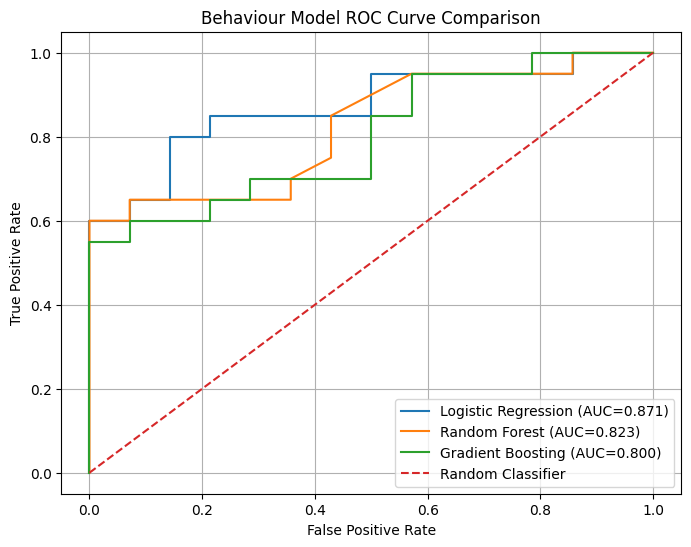

In [8]:
# plot ROC curve comparison for behaviour models - scaled features
plt.figure(figsize=(8,6))

for model_name, model in trained_behaviour_models.items():
    y_prob = model.predict_proba(X_beh_val_scaled_df)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_beh_val,
        y_prob
    )

    auc_score = roc_auc_score(
        y_beh_val,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Behaviour Model ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
# compare prediction probabilities of the models 
comparison = pd.DataFrame({
    "actual": y_beh_val
})

for name, model in trained_behaviour_models.items():
    comparison[name] = model.predict_proba(X_beh_val_scaled_df)[:, 1]

comparison.head(20)

,actual,Logistic Regression,Random Forest,Gradient Boosting
0,0,0.414672,0.61,0.294958
1,0,0.614190,0.47,0.476953
2,1,0.652437,0.66,0.676964
3,1,0.687086,0.68,0.926586
4,0,0.512950,0.62,0.538013
5,0,0.321830,0.56,0.576320
6,1,0.831462,0.74,0.923483
7,1,0.794060,0.52,0.392043
8,1,0.970682,0.96,0.993595
9,0,0.497947,0.61,0.876414


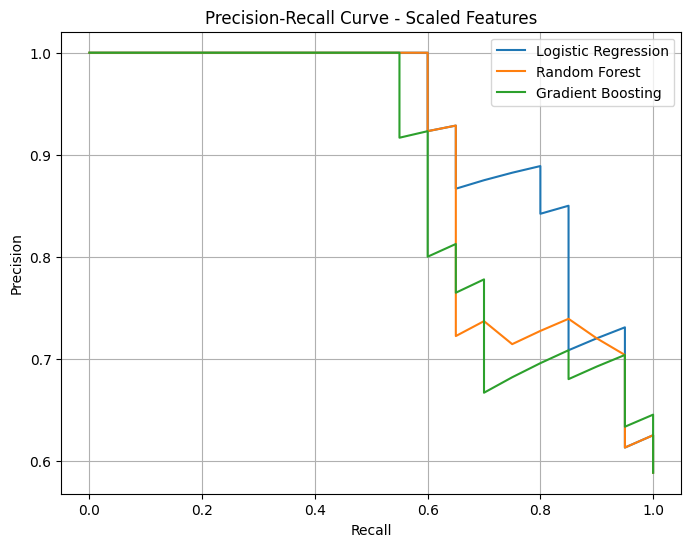

In [10]:
# precision-recall curve - scaled features 

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name, model in trained_behaviour_models.items():
    y_prob = model.predict_proba(X_beh_val_scaled_df)[:,1]

    precision, recall, _ = precision_recall_curve(
        y_beh_val,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Scaled Features")
plt.legend()
plt.grid(True)

plt.show()


In [11]:
# feature importance  of LR model - scaled features

lr = trained_behaviour_models["Logistic Regression"]

importance = pd.DataFrame({
    "feature": X_beh_train.columns,
    "coefficient": lr.coef_[0]
})

importance["abs_coef"] = importance["coefficient"].abs()

importance.sort_values(
    "abs_coef",
    ascending=False
)


,feature,coefficient,abs_coef
1,active_days,-0.642232,0.642232
9,assignment_views,-0.561544,0.561544
6,weekend_ratio,0.498186,0.498186
4,weekend_events,0.373494,0.373494
10,course_page_views,0.309227,0.309227
11,forum_views,-0.308369,0.308369
12,no_activity_flag,0.298556,0.298556
5,events_per_week,0.234304,0.234304
8,lecture_material_views,-0.124116,0.124116
2,unique_materials,-0.106577,0.106577


In [12]:
# feataure importance of RF model - scaled features
rf = trained_behaviour_models["Random Forest"]
rf_importance = pd.DataFrame({
    "feature": X_beh_train.columns,
    "importance": rf.feature_importances_
})
rf_importance.sort_values(
    "importance",
    ascending=False
)   

,feature,importance
9,assignment_views,0.098725
8,lecture_material_views,0.096542
6,weekend_ratio,0.095745
5,events_per_week,0.088394
3,after_hours_events,0.086977
11,forum_views,0.080064
0,total_events,0.078210
2,unique_materials,0.076850
4,weekend_events,0.075048
1,active_days,0.074882


In [13]:
# validation predictions table (LR model - scaled features)
lr = trained_behaviour_models["Logistic Regression"]

predictions = pd.DataFrame({
    "actual": y_beh_val,
    "predicted": lr.predict(X_beh_val_scaled_df),
    "risk_probability":
        lr.predict_proba(X_beh_val_scaled_df)[:,1]
})

predictions.sort_values(
    "risk_probability",
    ascending=False
).head(20)


,actual,predicted,risk_probability
8,1,1,0.970682
29,1,1,0.945055
22,1,1,0.832434
6,1,1,0.831462
23,1,1,0.794613
7,1,1,0.794060
16,1,1,0.760570
33,1,1,0.726966
10,1,1,0.723915
14,1,1,0.710193


In [14]:
# validation prediction table (RF model - scaled features)
rf = trained_behaviour_models["Random Forest"]

predictions = pd.DataFrame({
    "actual": y_beh_val,
    "predicted": rf.predict(X_beh_val_scaled_df),
    "risk_probability":
        rf.predict_proba(X_beh_val_scaled_df)[:,1]
})

predictions.sort_values(
    "risk_probability",
    ascending=False
).head(20)


,actual,predicted,risk_probability
20,1,1,0.96
8,1,1,0.96
29,1,1,0.94
13,1,1,0.81
14,1,1,0.81
23,1,1,0.76
16,1,1,0.76
6,1,1,0.74
28,1,1,0.70
3,1,1,0.68


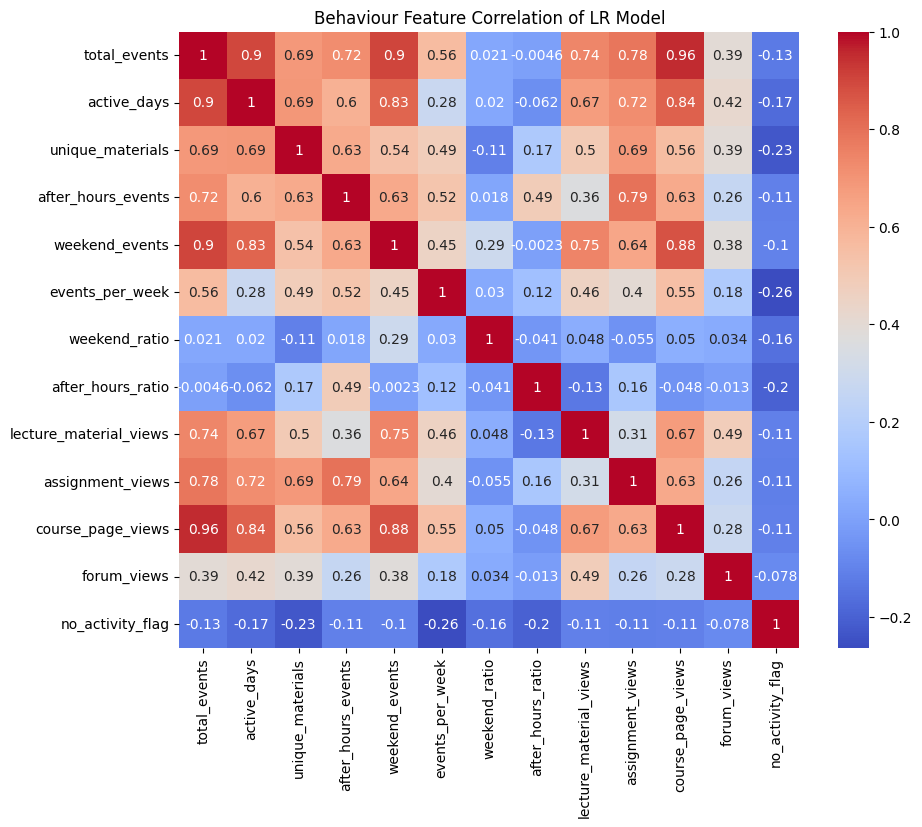

In [15]:
# feature correlation heatmap - scaled features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    X_beh_train.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Behaviour Feature Correlation of LR Model")

plt.show()

In [16]:
!pip install statsmodels

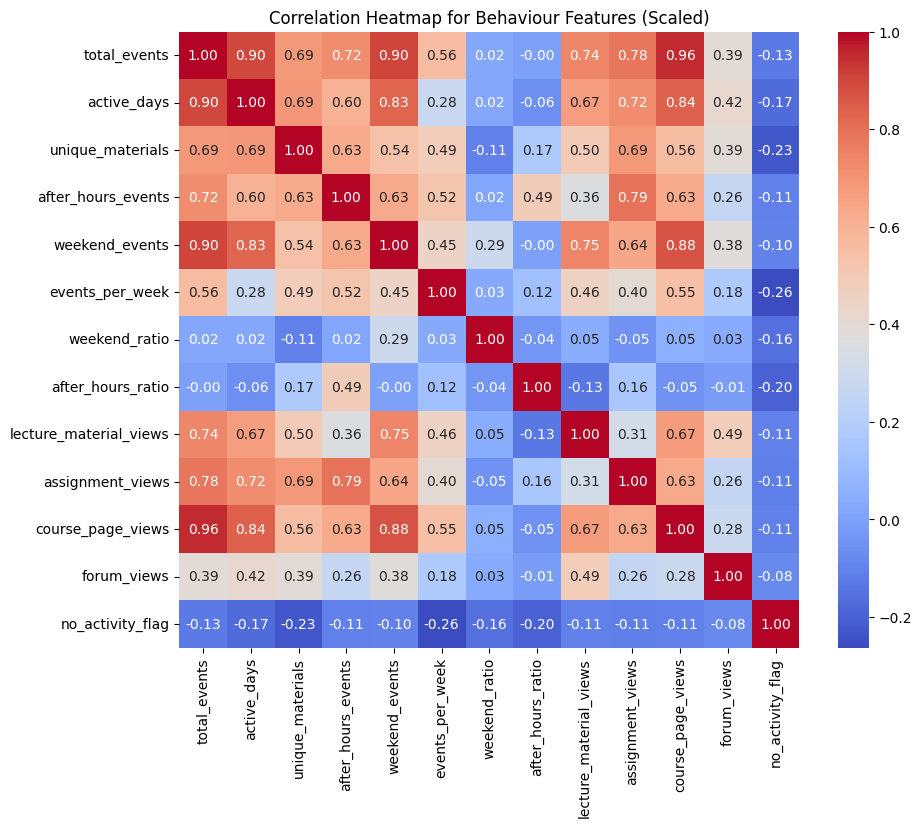

In [17]:
# check multicollinearity with VIF - scaled features
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame({
    "feature": X_beh_train.columns,
    "VIF": [variance_inflation_factor(X_beh_train_scaled, i) for i in range(X_beh_train_scaled.shape[1])]
})
vif_data.sort_values("VIF", ascending=False)

#plot multicollinearity correlation heatmap - scaled features
plt.figure(figsize=(10,8))
sns.heatmap(X_beh_train_scaled_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Behaviour Features (Scaled)")
plt.show()

### Experiment 2: Hyperparameter tuning 
best model from experiment 1 and test and compare parameters

In [18]:
# grid search for hyperparameter tuning - scaled features
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

# create a GridSearchCV object
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# fit the grid search to the training data
grid_search.fit(
    X_beh_train_scaled_df,
    y_beh_train
)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)


Best Parameters:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV ROC-AUC:
0.6830357142857142


In [19]:
# compare results tuned model on validation set - scaled features
tuned_results, tuned_model = evaluate_model(
    model_name="Tuned Logistic Regression",
    model=best_model,
    X_train=X_beh_train_scaled_df,
    y_train=y_beh_train,
    X_val=X_beh_val_scaled_df,
    y_val=y_beh_val,
    dataset_name="Behaviour"
)



=== Behaviour - Tuned Logistic Regression ===
Confusion Matrix:
[[ 7  7]
 [ 2 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.50      0.61        14
           1       0.72      0.90      0.80        20

    accuracy                           0.74        34
   macro avg       0.75      0.70      0.70        34
weighted avg       0.74      0.74      0.72        34



In [20]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_beh_val_scaled_df)[:,1]

roc_auc_score(
    y_beh_val,
    y_prob
)

0.8642857142857143

In [21]:
## retraining the final model on the combined training and validation datasets

# combine train + validation for final training
X_beh_final = pd.concat([X_beh_train, X_beh_val], axis=0)
y_beh_final = pd.concat([y_beh_train, y_beh_val], axis=0)

# fit scaler on final training data
final_behaviour_scaler = StandardScaler()
X_beh_final_scaled = final_behaviour_scaler.fit_transform(X_beh_final)

# train final tuned model
final_behaviour_model = LogisticRegression(
    C=0.1,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

final_behaviour_model.fit(X_beh_final_scaled, y_beh_final)

ROC_AUC_final = roc_auc_score(
    y_beh_final,
    final_behaviour_model.predict_proba(X_beh_final_scaled)[:,1]
)

In [22]:
# model metrics on final model - scaled features
from sklearn.metrics import auc


y_final_prob = final_behaviour_model.predict_proba(X_beh_final_scaled)[:,1]
print("Final Model ROC-AUC:", round(roc_auc_score(y_beh_final, y_final_prob), 2))

#confusion matrix
y_final_pred = final_behaviour_model.predict(X_beh_final_scaled)
print("Final Model Confusion Matrix:")
print(confusion_matrix(y_beh_final, y_final_pred))

f1 = round(f1_score(y_beh_final, y_final_pred), 2)
print("Final Model F1 Score:", f1)

precision = round(precision_score(y_beh_final, y_final_pred), 2)
print("Final Model Precision: ", precision)

recall = round(recall_score(y_beh_final, y_final_pred), 2)
print("Final Model Recall:", recall)

accuracy = round(accuracy_score(y_beh_final, y_final_pred), 2)
print("Final Model Accuracy:", accuracy)


Final Model ROC-AUC: 0.79
Final Model Confusion Matrix:
[[30 23]
 [12 68]]
Final Model F1 Score: 0.8
Final Model Precision:  0.75
Final Model Recall: 0.85
Final Model Accuracy: 0.74


In [23]:
import joblib
from pathlib import Path
import json

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

# save artifacts
joblib.dump(final_behaviour_model, model_dir / "behaviour_model_v1.pkl")
joblib.dump(final_behaviour_scaler, model_dir / "behaviour_scaler_v1.pkl")

metadata = {
    "model_name": "behaviour_risk_model",
    "model_version": "v1",
    "model_type": "Logistic Regression",
    "best_params": {"C": 0.1, "penalty": "l2", "solver": "lbfgs"},
    "accuracy": accuracy,
    "recall": recall,
    "precision": precision,
    "f1": f1,
    "roc_auc": round(roc_auc_score(y_beh_final, y_final_prob), 2)
}

with open(model_dir / "behaviour_model_metadata_v1.json", "w") as f:
    json.dump(metadata, f, indent=4)


## SELECTION FOR ACADEMIC MODEL 

### Experiment 1: Baseline Models Comparison 
1. Logistic Regression 
2. Random Forest 
3. Gradient Boosting 
4. Support Vector Machine

In [24]:
from sklearn.svm import SVC

In [25]:
# import and load academic datasets
X_aca_train = pd.read_csv("../datasets/X_aca_train.csv")
X_aca_val = pd.read_csv("../datasets/X_aca_val.csv")
y_aca_train = pd.read_csv("../datasets/y_aca_train.csv").squeeze()
y_aca_val = pd.read_csv("../datasets/y_aca_val.csv").squeeze()

In [26]:
# scale academic features
academic_scaler = StandardScaler()

X_aca_train_scaled = academic_scaler.fit_transform(X_aca_train)
X_aca_val_scaled = academic_scaler.transform(X_aca_val)

X_aca_train_scaled_df = pd.DataFrame(
    X_aca_train_scaled,
    columns=X_aca_train.columns,
    index=X_aca_train.index
)

X_aca_val_scaled_df = pd.DataFrame(
    X_aca_val_scaled,
    columns=X_aca_val.columns,
    index=X_aca_val.index
)

In [27]:
# define academic baseline models
academic_models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "use_scaled": True
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "use_scaled": False
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "use_scaled": False
    },
    "Support Vector Machine": {
        "model": SVC(probability=True, random_state=42),
        "use_scaled": True
    }
}

In [28]:
# evaluate baseline academic models
academic_results = []
trained_academic_models = {}

for model_name, config in academic_models.items():

    if config["use_scaled"]:
        X_train_used = X_aca_train_scaled_df
        X_val_used = X_aca_val_scaled_df
    else:
        X_train_used = X_aca_train
        X_val_used = X_aca_val

    result, trained_model = evaluate_model(
        model_name=model_name,
        model=config["model"],
        X_train=X_train_used,
        y_train=y_aca_train,
        X_val=X_val_used,
        y_val=y_aca_val,
        dataset_name="Academic"
    )

    academic_results.append(result)
    trained_academic_models[model_name] = trained_model

academic_results_df = pd.DataFrame(academic_results)

academic_results_df.sort_values(
    by=["recall", "f1", "roc_auc"],
    ascending=False
)


=== Academic - Logistic Regression ===
Confusion Matrix:
[[10  4]
 [ 3 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        14
           1       0.81      0.85      0.83        20

    accuracy                           0.79        34
   macro avg       0.79      0.78      0.79        34
weighted avg       0.79      0.79      0.79        34


=== Academic - Random Forest ===
Confusion Matrix:
[[ 9  5]
 [ 0 20]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.64      0.78        14
           1       0.80      1.00      0.89        20

    accuracy                           0.85        34
   macro avg       0.90      0.82      0.84        34
weighted avg       0.88      0.85      0.85        34


=== Academic - Gradient Boosting ===
Confusion Matrix:
[[ 7  7]
 [ 2 18]]

Classification Report:
              precision    recall  f1-score   suppo

,dataset,model,accuracy,precision,recall,f1,roc_auc
1,Academic,Random Forest,0.852941,0.800000,1.00,0.888889,0.898214
3,Academic,Support Vector Machine,0.794118,0.760000,0.95,0.844444,0.885714
2,Academic,Gradient Boosting,0.735294,0.720000,0.90,0.800000,0.878571
0,Academic,Logistic Regression,0.794118,0.809524,0.85,0.829268,0.946429


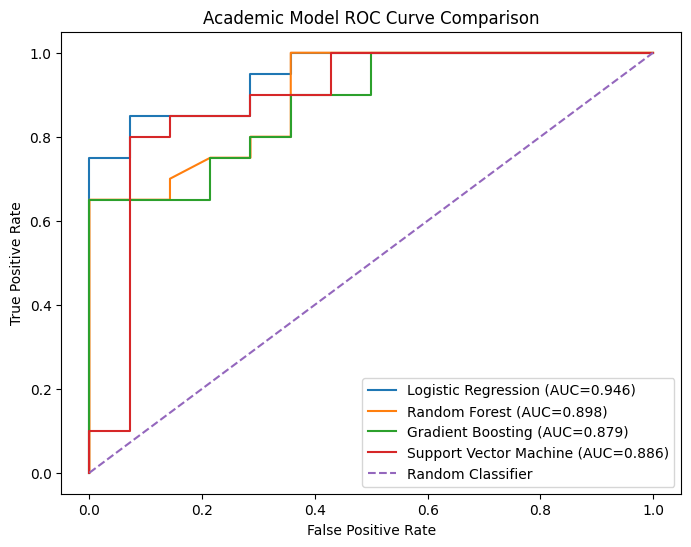

In [29]:
# ROC curve comparison for academic models
plt.figure(figsize=(8, 6))

for model_name, model in trained_academic_models.items():

    if academic_models[model_name]["use_scaled"]:
        X_val_used = X_aca_val_scaled_df
    else:
        X_val_used = X_aca_val

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val_used)[:, 1]
    else:
        y_prob = model.decision_function(X_val_used)

    fpr, tpr, _ = roc_curve(y_aca_val, y_prob)
    auc_score = roc_auc_score(y_aca_val, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Academic Model ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

In [30]:
# compare prediction probabilities of all academic models
comparison_academic = pd.DataFrame({
    "actual": y_aca_val
})

for name, model in trained_academic_models.items():

    if academic_models[name]["use_scaled"]:
        X_val_used = X_aca_val_scaled_df
    else:
        X_val_used = X_aca_val

    if hasattr(model, "predict_proba"):
        comparison_academic[name] = model.predict_proba(X_val_used)[:, 1]
    else:
        comparison_academic[name] = model.decision_function(X_val_used)

comparison_academic.sort_values(
    by="actual",
    ascending=False
).head(20)

,actual,Logistic Regression,Random Forest,Gradient Boosting,Support Vector Machine
33,1,0.953308,0.89,0.997075,0.909552
22,1,0.890853,0.73,0.980707,0.858840
20,1,0.999858,1.00,0.997577,0.852726
24,1,0.494699,0.57,0.768916,0.681225
25,1,0.722182,0.66,0.748419,0.845676
26,1,0.816316,0.57,0.808638,0.742308
16,1,0.999320,1.00,0.997577,0.854941
14,1,0.841852,0.64,0.943842,0.865048
13,1,0.983901,1.00,0.997577,0.865051
28,1,0.481238,0.57,0.340014,0.630654


In [31]:
comparison_academic[
    comparison_academic["actual"] == 0
]

,actual,Logistic Regression,Random Forest,Gradient Boosting,Support Vector Machine
0,0,0.248649,0.44,0.234778,0.311057
1,0,0.457803,0.66,0.804534,0.642625
4,0,0.601626,0.80,0.980450,0.732559
5,0,0.140501,0.00,0.002747,0.156117
9,0,0.154260,0.03,0.002947,0.139001
11,0,0.234142,0.28,0.062940,0.198436
12,0,0.779561,0.79,0.975613,0.885558
15,0,0.339042,0.45,0.633010,0.726639
17,0,0.680850,0.65,0.929956,0.768268
18,0,0.648997,0.62,0.972039,0.675915


In [32]:
comparison_academic.sort_values(
    "Gradient Boosting",
    ascending=False
).tail(20)

,actual,Logistic Regression,Random Forest,Gradient Boosting,Support Vector Machine
12,0,0.779561,0.79,0.975613,0.885558
18,0,0.648997,0.62,0.972039,0.675915
32,1,0.989082,0.97,0.950384,0.839567
14,1,0.841852,0.64,0.943842,0.865048
17,0,0.680850,0.65,0.929956,0.768268
26,1,0.816316,0.57,0.808638,0.742308
1,0,0.457803,0.66,0.804534,0.642625
24,1,0.494699,0.57,0.768916,0.681225
25,1,0.722182,0.66,0.748419,0.845676
27,0,0.196380,0.45,0.648391,0.508062


In [33]:
comparison_academic.groupby("actual")[
    "Gradient Boosting"
].describe()

,count,mean,std,min,25%,50%,75%,max
actual,,,,,,,,
0,14.0,0.450248,0.430935,0.002747,0.017928,0.433894,0.898601,0.980450
1,20.0,0.895143,0.194741,0.340014,0.910041,0.992499,0.997577,0.998447


In [34]:
# helper function to choose correct validation features 
def get_academic_validation_features(model_name):
    if academic_models[model_name]["use_scaled"]:
        return X_aca_val_scaled_df
    return X_aca_val

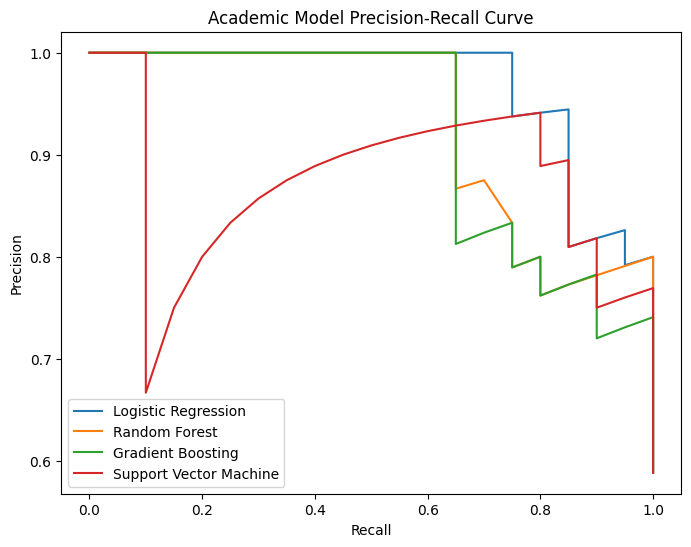

In [35]:
# precision recall curve comparison for academic models
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for model_name, model in trained_academic_models.items():

    X_val_used = get_academic_validation_features(model_name)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val_used)[:, 1]
    else:
        y_prob = model.decision_function(X_val_used)

    precision, recall, _ = precision_recall_curve(
        y_aca_val,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=model_name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Academic Model Precision-Recall Curve")
plt.legend()
plt.show()


In [36]:
# feature imporance LR 
lr = trained_academic_models["Logistic Regression"]

lr_importance = pd.DataFrame({
    "feature": X_aca_train.columns,
    "coefficient": lr.coef_[0]
})

lr_importance["abs_coefficient"] = lr_importance["coefficient"].abs()

lr_importance.sort_values(
    "abs_coefficient",
    ascending=False
)

,feature,coefficient,abs_coefficient
3,pass_assessment_count,-1.065402,1.065402
4,latest_assessment_score,-0.668129,0.668129
7,late_exercise_avg,-0.654834,0.654834
6,early_exercise_avg,-0.559222,0.559222
0,avg_score_so_far,-0.547208,0.547208
9,score_trend,0.302009,0.302009
2,min_score_so_far,0.264038,0.264038
8,assignment_avg_score,-0.151246,0.151246
1,max_score_so_far,-0.095356,0.095356
5,fail_assessment_count,-0.062515,0.062515


In [37]:
# feature importance RF
rf = trained_academic_models["Random Forest"]

rf_importance = pd.DataFrame({
    "feature": X_aca_train.columns,
    "importance": rf.feature_importances_
})

rf_importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
0,avg_score_so_far,0.219440
4,latest_assessment_score,0.158568
3,pass_assessment_count,0.138329
2,min_score_so_far,0.108653
7,late_exercise_avg,0.090916
6,early_exercise_avg,0.087134
9,score_trend,0.071462
8,assignment_avg_score,0.068384
5,fail_assessment_count,0.038207
1,max_score_so_far,0.018907


In [38]:
# feature importance GB
gb = trained_academic_models["Gradient Boosting"]

gb_importance = pd.DataFrame({
    "feature": X_aca_train.columns,
    "importance": gb.feature_importances_
})

gb_importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
3,pass_assessment_count,0.366275
4,latest_assessment_score,0.198400
6,early_exercise_avg,0.117024
0,avg_score_so_far,0.116657
9,score_trend,0.098793
8,assignment_avg_score,0.033094
2,min_score_so_far,0.030813
5,fail_assessment_count,0.020835
7,late_exercise_avg,0.017706
1,max_score_so_far,0.000403


In [39]:
# validation predictions table 
validation_predictions = pd.DataFrame({
    "actual": y_aca_val
})

for name, model in trained_academic_models.items():

    if academic_models[name]["use_scaled"]:
        X_val_used = X_aca_val_scaled_df
    else:
        X_val_used = X_aca_val

    validation_predictions[f"{name}_prob"] = (
        model.predict_proba(X_val_used)[:, 1]
        if hasattr(model, "predict_proba")
        else model.decision_function(X_val_used)
    )

    validation_predictions[f"{name}_pred"] = (
        validation_predictions[f"{name}_prob"] >= 0.5
    ).astype(int)

validation_predictions.head(20)

,actual,Logistic Regression_prob,Logistic Regression_pred,Random Forest_prob,Random Forest_pred,Gradient Boosting_prob,Gradient Boosting_pred,Support Vector Machine_prob,Support Vector Machine_pred
0,0,0.248649,0,0.44,0,0.234778,0,0.311057,0
1,0,0.457803,0,0.66,1,0.804534,1,0.642625,1
2,1,0.952827,1,0.88,1,0.993544,1,0.878056,1
3,1,0.802091,1,0.92,1,0.991454,1,0.848951,1
4,0,0.601626,1,0.80,1,0.980450,1,0.732559,1
5,0,0.140501,0,0.00,0,0.002747,0,0.156117,0
6,1,0.454559,0,0.59,1,0.412398,0,0.523913,1
7,1,0.765995,1,0.86,1,0.989505,1,0.823080,1
8,1,0.999865,1,1.00,1,0.997577,1,0.848455,1
9,0,0.154260,0,0.03,0,0.002947,0,0.139001,0


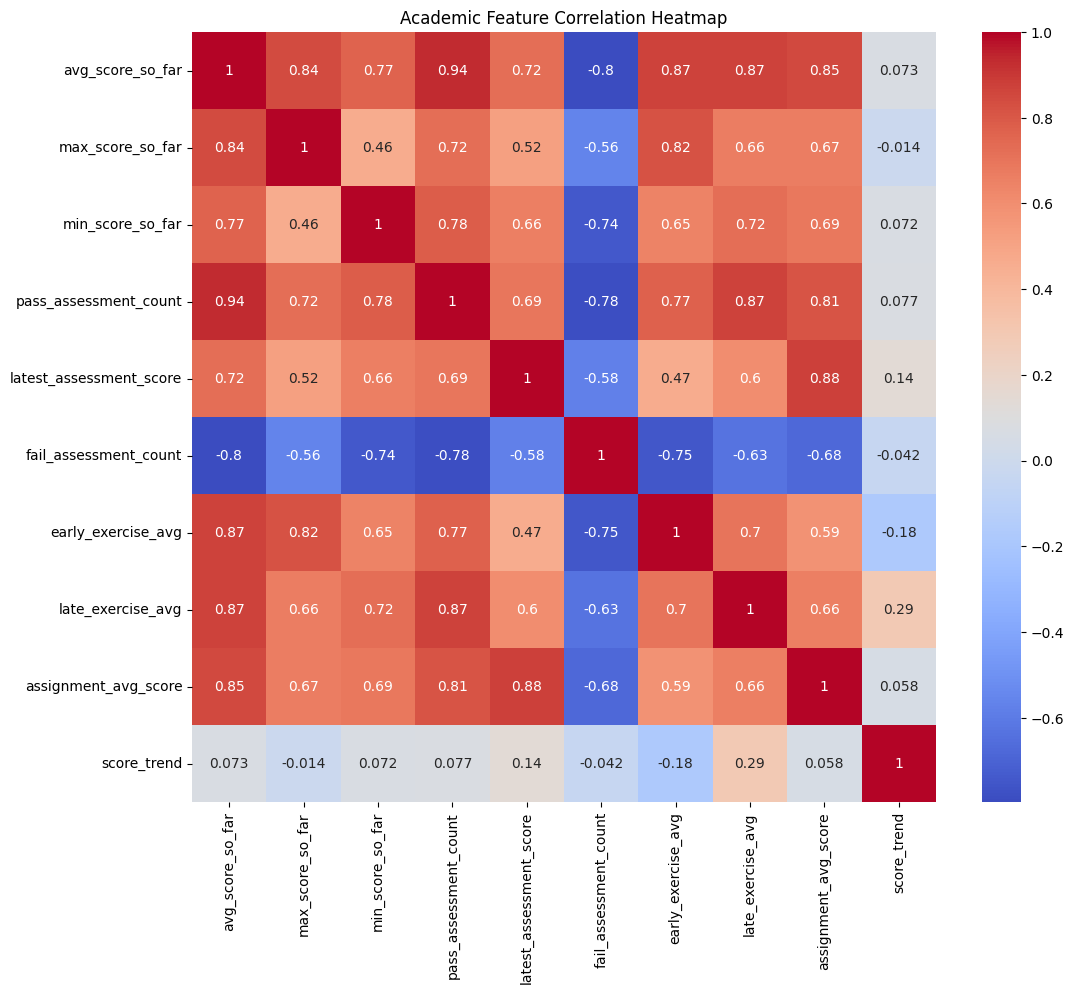

In [40]:
# academic feature correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

sns.heatmap(
    X_aca_train.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Academic Feature Correlation Heatmap")
plt.show()

In [41]:
rf_importance.sort_values(
    "importance",
    ascending=False
)

gb_importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
3,pass_assessment_count,0.366275
4,latest_assessment_score,0.198400
6,early_exercise_avg,0.117024
0,avg_score_so_far,0.116657
9,score_trend,0.098793
8,assignment_avg_score,0.033094
2,min_score_so_far,0.030813
5,fail_assessment_count,0.020835
7,late_exercise_avg,0.017706
1,max_score_so_far,0.000403


# Experiment 2: Hyperparameter tuning on the best performer


In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [43]:
# parameter grid for Random Forest
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [45]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_aca_train, y_aca_train)
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV F1:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV F1:
0.8297101449275361


In [46]:
# evaluate tuned model
best_rf = rf_grid.best_estimator_

y_pred = best_rf.predict(X_aca_val)

print(classification_report(
    y_aca_val,
    y_pred
))

              precision    recall  f1-score   support

           0       0.75      0.64      0.69        14
           1       0.77      0.85      0.81        20

    accuracy                           0.76        34
   macro avg       0.76      0.75      0.75        34
weighted avg       0.76      0.76      0.76        34



         Model  F1 Score
0  RF Baseline  0.888889
1     RF Tuned  0.829710
         Model  Recall
0  RF Baseline    1.00
1     RF Tuned    0.85


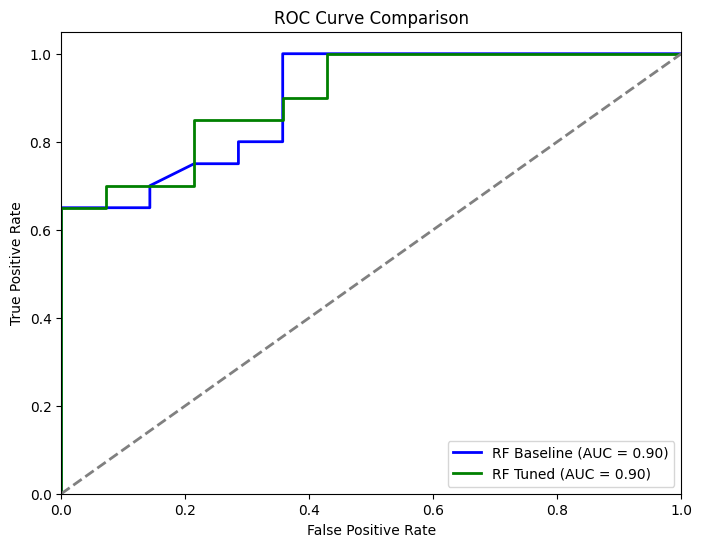

In [48]:
# create a table to compare RF baseline vs tuned model metrics


rf_baseline_f1 = f1_score(y_aca_val, rf.predict(X_aca_val))

baseline_metrics = {
    "Model": ["RF Baseline", "RF Tuned"],
    "F1 Score": [rf_baseline_f1, rf_grid.best_score_]
}

metrics_df = pd.DataFrame(baseline_metrics)
print(metrics_df)

# recall comparison
rf_baseline_recall = recall_score(y_aca_val, rf.predict(X_aca_val))
rf_tuned_recall = recall_score(y_aca_val, best_rf.predict(X_aca_val))
recall_comparison = {
    "Model": ["RF Baseline", "RF Tuned"],
    "Recall": [rf_baseline_recall, rf_tuned_recall]
}
recall_df = pd.DataFrame(recall_comparison)
print(recall_df)

# ROC curve comparison for baseline vs tuned RF model
plt.figure(figsize=(8, 6))

# Baseline RF model
fpr_baseline, tpr_baseline, _ = roc_curve(y_aca_val, rf.predict_proba(X_aca_val)[:, 1])
roc_auc_baseline = auc(fpr_baseline, tpr_baseline)
plt.plot(fpr_baseline, tpr_baseline, color='blue', lw=2, label='RF Baseline (AUC = %0.2f)' % roc_auc_baseline)

# Tuned RF model
fpr_tuned, tpr_tuned, _ = roc_curve(y_aca_val, best_rf.predict_proba(X_aca_val)[:, 1])
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)
plt.plot(fpr_tuned, tpr_tuned, color='green', lw=2, label='RF Tuned (AUC = %0.2f)' % roc_auc_tuned)

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()


In [49]:
# threshold tuning for RF baseline model
thresholds = [0.3, 0.4, 0.5, 0.6]

rf = trained_academic_models["Random Forest"]

y_prob = rf.predict_proba(X_aca_val)[:, 1]

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_aca_val, y_pred),
        "recall": recall_score(y_aca_val, y_pred),
        "f1": f1_score(y_aca_val, y_pred)
    })

pd.DataFrame(results)

,threshold,precision,recall,f1
0,0.3,0.689655,1.0,0.816327
1,0.4,0.714286,1.0,0.833333
2,0.5,0.800000,1.0,0.888889
3,0.6,0.761905,0.8,0.780488


In [50]:
# retrain the baseline RF model on the combined training and validation datasets
X_aca_final = pd.concat([X_aca_train, X_aca_val], axis=0)
y_aca_final = pd.concat([y_aca_train, y_aca_val], axis=0)
print(X_aca_final.shape)
# metrics on the final model
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_aca_final, y_aca_final)
y_final_pred = rf_final.predict(X_aca_final)
print("Final Model Metrics:")
print("Precision:", precision_score(y_aca_final, y_final_pred))
print("Recall:", recall_score(y_aca_final, y_final_pred))
print("F1 Score:", f1_score(y_aca_final, y_final_pred))

(133, 10)
Final Model Metrics:
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [51]:
# save the final model 
import joblib
import json
from pathlib import Path
from datetime import datetime

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

final_academic_model = trained_academic_models["Random Forest"]

joblib.dump(
    final_academic_model,
    model_dir / "academic_model_v1.pkl"
)

metadata = {
    "model_name": "academic_risk_model",
    "model_version": "v1",
    "algorithm": "Random Forest",
    "selected_model": "Baseline Random Forest",
    "threshold": 0.5,
    "features": list(X_aca_train.columns),
    "accuracy": 0.852941,
    "precision": 0.800000,
    "recall": 1.000000,
    "f1": 0.888889,
    "roc_auc": 0.898214,
    "created_at": datetime.now().isoformat(),
    "artifact_path": "ml/models/academic_model_v1.pkl"
}

with open(model_dir / "academic_model_metadata_v1.json", "w") as f:
    json.dump(metadata, f, indent=4)